# 03 - DDIM 确定性采样

> **02 的 DDPM 虽然好训练，但有一个原罪：推理要 1000 步。**
> **03 的 DDIM 不改变训练，只改变采样——同一个训练好的模型，用 DDIM 采样 50 步能出图，质量几乎不掉。**

**一句话直觉**：DDIM 把 DDPM 的"随机游走"换成了"顺着一条确定的路径往下滑"。没了随机性 → 步子可以迈大 → 50 步顶 DDPM 1000 步。

---

**符号提醒**：$x_0$ / $x_t$ / $\bar\alpha_t$ / $\epsilon_\theta$ / $\sigma_t$ 忘了？回 01 课符号表和 02 课新增表。本课新增：

| 新符号 | 含义 |
|--------|------|
| $\eta$ | 随机性总开关：0 = DDIM（确定性），1 = DDPM（随机） |
| $\Delta$ | 一次跳过的时间步数（跳步步长） |
| $\hat x_0$ | 用当前 $\epsilon$-预测反解出的"$x_0$ 估计值" |

---

**这个 notebook 的 KPI**：
- 理解 DDPM (SDE) vs DDIM (ODE) 的核心区别
- 记住 $\eta$ 参数的含义（0=DDIM, 1=DDPM）
- 能解释**为什么同一个模型能两种采样都用**
- 知道 **DDIM inversion** 是什么、为什么它是图像编辑的基础

## 核心 motivation：DDPM 为什么跳步会掉质量？

DDPM 的反向采样把每一步 $x_t \to x_{t-1}$ 建模成一个**高斯分布**。关键在于：真实的反向条件分布**只在步长很小时才近似高斯**。

**如果你想跳步**（比如 $x_T \to x_{T-50}$ 直接跳 50 步）：
- 大步长下真实的反向条件分布已经不是高斯（可能多峰、歪斜）
- DDPM 的高斯反向核硬套上去 → 近似失效 → 质量掉得快
- 注意：DDPM 也**能** respacing 跳步（iDDPM 就这么干），不是"一跳就崩"，只是掉质量比 DDIM 快得多

**DDIM 的关键洞察**：如果把整个采样过程看成一个**确定性常微分方程 (ODE) 的数值积分**，那么：
- 步长可以大（只要数值积分误差可控）
- 不依赖"每步高斯"的假设
- 每一步都是 deterministic 的，同一个 $x_T$ 得到同一个 $x_0$

**这就从根本上解决了 DDPM 的慢。**

## DDPM vs DDIM：SDE vs ODE 对比

| 维度 | DDPM | DDIM |
|------|------|------|
| 建模视角 | 随机过程 (SDE) | 常微分方程 (ODE) |
| 每步随机性 | 有（$\sigma_t z$） | 无（$\eta=0$）|
| 典型步数 | 1000 | **50** |
| 同一 $x_T$ → 同一 $x_0$？ | ❌ | ✅ |
| 可以 inversion 吗？ | ❌ | ✅ |
| 训练有变化吗？ | — | **完全相同**（复用 DDPM 模型）|

**最后一点最关键**：DDIM 不需要重新训练。它只是把同一个训练好的 $\epsilon_\theta$ 用不同方式做采样。这是 DDIM 被工业大规模采用的核心原因——零成本升级。

## DDIM 采样公式（一页纸）

给定训练好的 $\epsilon_\theta$，从 $x_t$ 跳到 $x_{t-\Delta}$（可跳步）：

**Step 1**：用 $\epsilon$-pred 反推一个"当前估计的 $x_0$"

$$\hat{x}_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t, t)}{\sqrt{\bar\alpha_t}}$$

**Step 2**：把这个 $\hat{x}_0$ 和当前的 $\epsilon$ 按 $t-\Delta$ 时刻的 schedule 重新合成

> Step 2 在干什么：拿着刚估出的 $\hat x_0$，**假装重新做一次前向加噪**，但噪声不重新抽，直接复用 $\epsilon_\theta$——$\eta=0$ 时全程没有新随机数。"先拆回 $x_0$，再装到目标时刻"就是 DDIM 跳步的全部秘密。

$$x_{t-\Delta} = \sqrt{\bar\alpha_{t-\Delta}}\,\hat{x}_0 + \sqrt{1-\bar\alpha_{t-\Delta} - \sigma^2}\,\epsilon_\theta + \sigma z$$

其中

$$\sigma = \eta \cdot \sqrt{\frac{1-\bar\alpha_{t-\Delta}}{1-\bar\alpha_t}} \cdot \sqrt{1 - \frac{\bar\alpha_t}{\bar\alpha_{t-\Delta}}}$$

> 📖 读式子：$\sigma$ 由三个因子相乘。
> 1. $\eta$：你手动拧的**总开关**（0 = 关死随机性）
> 2. $\sqrt{(1-\bar\alpha_{t-\Delta})/(1-\bar\alpha_t)}$：目标时刻 / 当前时刻的**噪声水平之比**（< 1）
> 3. $\sqrt{1 - \bar\alpha_t/\bar\alpha_{t-\Delta}}$：这一跳跨过的**信号衰减**，跳越远越大
>
> 极端检查①：$\eta = 0 \Rightarrow \sigma = 0$，纯确定性 ✓
> 极端检查②：$\eta = 1$ 且 $\Delta = 1$ 时 $\sigma^2 = \tilde\beta_t$，正好是 DDPM 的后验方差——**DDPM 是 DDIM 的特例，不是两个模型**（下面有代码验证）

**$\eta$ 是 DDIM 最重要的参数**：
- $\eta = 0$：**DDIM**，纯确定性，$\sigma=0$ 那个随机项消失
- $\eta = 1$：**DDPM**，恢复原版随机采样
- $0 < \eta < 1$：插值，工业上偶尔用来做 quality/diversity 权衡

**直觉**：DDIM 就是"先用当前 $\epsilon$ 估一个干净的 $\hat{x}_0$，再按目标时间步的 schedule 重新加噪到位"。**两步即跳**，不走 Markov 链。

## 代码手撕（DDIM 采样，一个函数搞定）

我们直接复用 02 训练好的模型，不重训。

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 复用 02 训练好的模型 - 重新构建结构并重跑训练（小模型，30秒搞定）
# 原则：03 的重点是采样对比，不重训练
torch.manual_seed(42); np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [2]:
import torch.nn.functional as F

class SinusoidalTimeEmbed(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-np.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class TinyDenoiser(nn.Module):
    def __init__(self, img_size=16, hidden=256, t_dim=64):
        super().__init__()
        self.img_size = img_size
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbed(t_dim), nn.Linear(t_dim, hidden),
            nn.SiLU(), nn.Linear(hidden, hidden))
        self.net = nn.Sequential(
            nn.Linear(img_size*img_size, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, img_size*img_size))
    def forward(self, x, t):
        B = x.size(0)
        h = x.view(B, -1)
        t_emb = self.time_embed(t)
        h = self.net[0](h); h = h + t_emb
        for layer in self.net[1:]:
            h = layer(h)
        return h.view(B, 1, self.img_size, self.img_size)

def make_seven(n=256, size=16):
    imgs = []
    for _ in range(n):
        img = -torch.ones(size, size)
        img[2:4, 2:13] = 1.0
        offset = np.random.randint(-1, 2)
        for i, col in enumerate(range(12+offset, 3+offset, -1)):
            row = 3 + i * (size-5) // 10
            if 0 <= row < size and 0 <= col < size:
                img[row:row+2, col-1:col+1] = 1.0
        img += torch.randn_like(img) * 0.05
        imgs.append(img)
    return torch.stack(imgs).unsqueeze(1)

# 训练
model = TinyDenoiser().to(device)
T = 200
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1. - betas
alpha_bars = torch.cumprod(alphas, dim=0)
sqrt_ab = torch.sqrt(alpha_bars); sqrt_1mab = torch.sqrt(1-alpha_bars)

x_train = make_seven(512).to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
for step in range(300):
    idx = torch.randperm(x_train.size(0))[:128]
    x0 = x_train[idx]
    t = torch.randint(0, T, (x0.size(0),), device=device)
    eps = torch.randn_like(x0)
    xt = sqrt_ab[t,None,None,None]*x0 + sqrt_1mab[t,None,None,None]*eps
    loss = F.mse_loss(model(xt, t), eps)
    opt.zero_grad(); loss.backward(); opt.step()
print(f'Trained, final loss: {loss.item():.4f}')

Trained, final loss: 0.6020


### 通用采样函数（DDPM / DDIM 一套代码搞定）

用 `eta` 参数统一控制：`eta=1` 是 DDPM，`eta=0` 是 DDIM。

In [3]:
@torch.no_grad()
def sample(model, n, steps, alpha_bars, T, eta=0.0, img_size=16, device='cpu'):
    """
    通用 diffusion 采样器。
      eta=0   -> DDIM (确定性)
      eta=1   -> DDPM (原版随机)
      steps   -> 实际采样步数，可 << T (跳步)
    """
    model.eval()
    # 从 T 中等间距取 steps 个时间点
    # 注意：linspace + long 截断在 steps 接近 T 时会产生重复时间步（重复步相当于原地不动），
    # 教学演示无妨；严谨实现可用 np.arange(0, T, T//steps) 这类整数间隔
    t_seq = torch.linspace(T-1, 0, steps+1).long().to(device)
    x = torch.randn(n, 1, img_size, img_size, device=device)

    for i in range(steps):
        t_cur, t_next = t_seq[i].item(), t_seq[i+1].item()
        ab_cur  = alpha_bars[t_cur]
        ab_next = alpha_bars[t_next] if t_next >= 0 else torch.tensor(1.0, device=device)

        t_batch = torch.full((n,), t_cur, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)

        # Step 1: 估 x0
        x0_pred = (x - torch.sqrt(1-ab_cur) * eps_pred) / torch.sqrt(ab_cur)
        x0_pred = x0_pred.clamp(-1, 1)  # 稳定性

        # Step 2: sigma (eta 控制随机性)
        sigma = eta * torch.sqrt((1-ab_next)/(1-ab_cur)) * torch.sqrt(1 - ab_cur/ab_next) if t_next >= 0 else 0

        # Step 3: 重新合成 x_{t-1}
        dir_xt = torch.sqrt(torch.clamp(1 - ab_next - sigma**2, min=0)) * eps_pred
        noise = sigma * torch.randn_like(x) if eta > 0 and t_next >= 0 else 0
        x = torch.sqrt(ab_next) * x0_pred + dir_xt + noise

    model.train()
    return x

### 3 行验证："η=1 恢复 DDPM"不是口号，是恒等式

上面读式子说 $\eta=1, \Delta=1$ 时 $\sigma^2$ 正好等于 DDPM 的后验方差 $\tilde\beta_t = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t$。别信我，跑一下：

In [4]:
# 验证：eta=1, Delta=1 时 DDIM 的 sigma^2 == DDPM 后验方差 beta_tilde_t（对所有 t 成立）
# 注意：要用 float64 重建 schedule 再验证。float32 的 cumprod 舍入误差在
# 1 - abar_t/abar_{t-1} 这种"两个近乎相等的数相除再和 1 相减"的式子里会被放大到
# beta_t（~1e-4）的量级之上，allclose 会误报——恒等式验证要当心浮点，这本身是个小教训
betas64 = torch.linspace(1e-4, 0.02, T, dtype=torch.float64)
abar64  = torch.cumprod(1.0 - betas64, dim=0)
t_idx = torch.arange(1, T)
sigma2_ddim = (1 - abar64[t_idx-1]) / (1 - abar64[t_idx]) * (1 - abar64[t_idx] / abar64[t_idx-1])
beta_tilde  = (1 - abar64[t_idx-1]) / (1 - abar64[t_idx]) * betas64[t_idx]
assert torch.allclose(sigma2_ddim, beta_tilde), 'DDIM eta=1 应恢复 DDPM 后验方差'
print(f'所有 {len(t_idx)} 个时间步上 sigma^2(eta=1) == beta_tilde_t ✓  DDPM 是 DDIM 的特例')

所有 199 个时间步上 sigma^2(eta=1) == beta_tilde_t ✓  DDPM 是 DDIM 的特例


### 对比实验：DDIM 50 步 vs DDPM 200 步

/tmp/ipykernel_480635/3668131844.py:19: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_480635/3668131844.py:19: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_480635/3668131844.py:19: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_480635/3668131844.py:19: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_480635/3668131844.py:19: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_480635/3668131844.py:19: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_480635/3668131844

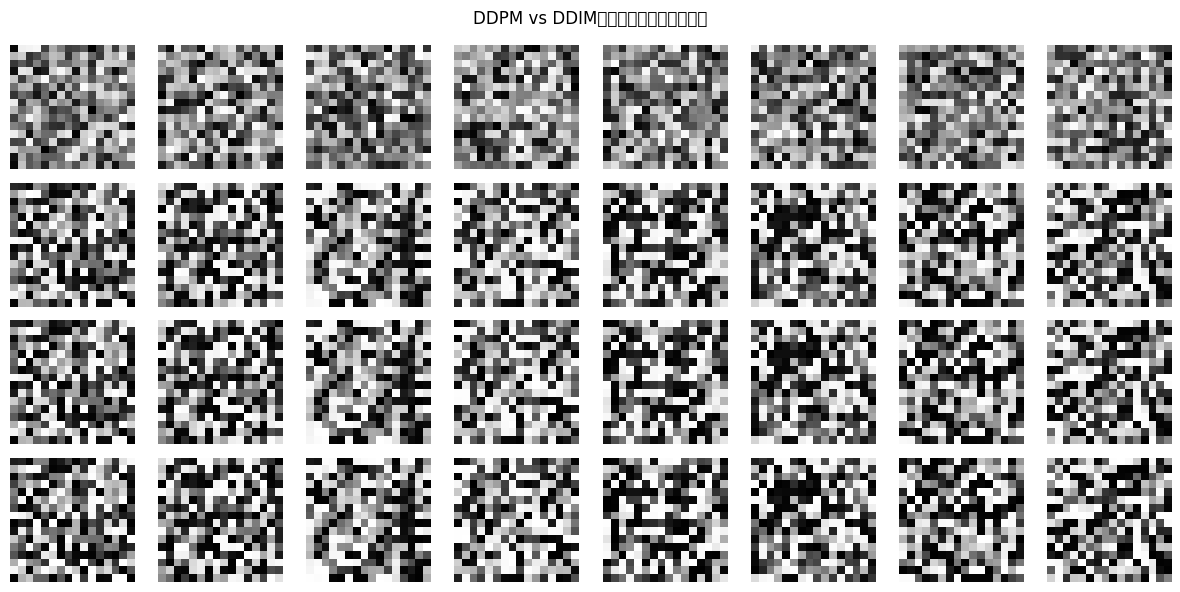

In [5]:
torch.manual_seed(0)
samples_ddpm = sample(model, 8, steps=200, alpha_bars=alpha_bars, T=T, eta=1.0, device=device)
torch.manual_seed(0)
samples_ddim_200 = sample(model, 8, steps=200, alpha_bars=alpha_bars, T=T, eta=0.0, device=device)
torch.manual_seed(0)
samples_ddim_50  = sample(model, 8, steps=50,  alpha_bars=alpha_bars, T=T, eta=0.0, device=device)
torch.manual_seed(0)
samples_ddim_10  = sample(model, 8, steps=10,  alpha_bars=alpha_bars, T=T, eta=0.0, device=device)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
labels = ['DDPM (η=1, 200 步)', 'DDIM (η=0, 200 步)', 'DDIM (η=0, 50 步)', 'DDIM (η=0, 10 步)']
rows = [samples_ddpm, samples_ddim_200, samples_ddim_50, samples_ddim_10]
for r, (lbl, imgs) in enumerate(zip(labels, rows)):
    for c in range(8):
        axes[r, c].imshow(imgs[c, 0].cpu(), cmap='gray', vmin=-1, vmax=1)
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(lbl, fontsize=10, rotation=0, ha='right', va='center')
plt.suptitle('DDPM vs DDIM：同一模型，不同采样器')
plt.tight_layout(); plt.show()

**关键观察**：
- DDPM 200 步 vs DDIM 200 步：视觉差不多（DDIM 是 DDPM 的 ODE 极限，质量相当）
- DDIM 50 步：基本还是能看出形状（**4× 加速几乎免费**）
- DDIM 10 步：开始糊（步子太大，ODE 积分误差累积）

**工业实践**：SD1.5 / SD2 时代的经典配置是 **DDIM 50 步**（注意官方脚本默认并非 DDIM），SDXL 时代常用 **Euler / DPM++ 20-30 步**（更高阶的 ODE solver，后续 notebook 会讲）。

## DDIM Inversion：图像编辑的基础

**工业场景**：给你一张真实的猫照片，你想把它变成"戴着皇冠的同一只猫"，但**猫的形态要保持不变**。怎么做？

**DDIM Inversion 的思路**：
1. **逆向**：把真实图 $x_0$ 沿着 DDIM ODE **反向**跑一遍 → 得到对应的 $x_T$（某个特定的噪声向量）
2. **编辑**：改 prompt、或用 attention injection / ControlNet 等手段
3. **前向**：从那个 $x_T$ 再 DDIM 正向采样 → 得到编辑后的图，但保持原图结构

**为什么 DDPM 不行？** 因为 DDPM 每步都加随机噪声，逆不回去（你不知道当时加的是哪个 $z$）。DDIM 是确定性的，**可逆**。

这是**所有 SD-based 图像编辑算法的底层基础**：
- Null-text Inversion (CVPR 2023)
- Prompt-to-Prompt
- DiffEdit
- InstructPix2Pix 的某些变体

**📝 面试高频题**：问你"Stable Diffusion 怎么做图像编辑"，答案的起点就是"DDIM Inversion"。

/tmp/ipykernel_480635/3382109913.py:49: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_480635/3382109913.py:49: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_480635/3382109913.py:49: UserWarning: Glyph 36870 (\N{CJK UNIFIED IDEOGRAPH-9006}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_480635/3382109913.py:49: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_480635/3382109913.py:49: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_480635/3382109913.py:49: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipyke

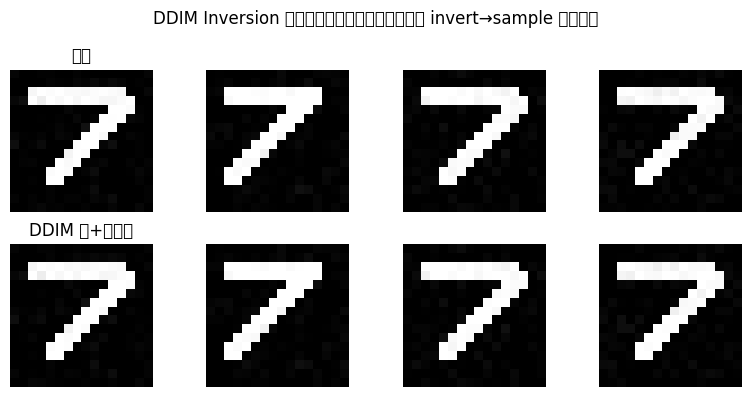

In [6]:
# 简易 DDIM Inversion 演示：把训练集里的一张图逆回噪声再正向采样，看能不能恢复

@torch.no_grad()
def ddim_invert(model, x0, steps, alpha_bars, T, device):
    """把 x0 逆向跑 DDIM ODE，得到对应的 x_T。"""
    model.eval()
    t_seq = torch.linspace(0, T-1, steps+1).long().to(device)
    x = x0.clone()
    for i in range(steps):
        t_cur, t_next = t_seq[i].item(), t_seq[i+1].item()
        ab_cur = alpha_bars[t_cur] if t_cur >= 1 else torch.tensor(1.0, device=device)
        ab_next = alpha_bars[t_next]
        t_batch = torch.full((x.size(0),), t_cur, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)
        x0_pred = (x - torch.sqrt(1-ab_cur)*eps_pred) / torch.sqrt(ab_cur) if t_cur >= 1 else x
        x = torch.sqrt(ab_next) * x0_pred + torch.sqrt(1-ab_next) * eps_pred
    return x

x_real = x_train[:4].clone()
x_T_inv = ddim_invert(model, x_real, 50, alpha_bars, T, device)

# 从逆向得到的 x_T_inv 出发做 DDIM 正向采样（全程确定性，不引入新随机数）
@torch.no_grad()
def sample_from_xT(model, x_T, steps, alpha_bars, T, device):
    model.eval()
    t_seq = torch.linspace(T-1, 0, steps+1).long().to(device)
    x = x_T.clone()
    for i in range(steps):
        t_cur, t_next = t_seq[i].item(), t_seq[i+1].item()
        ab_cur = alpha_bars[t_cur]
        ab_next = alpha_bars[t_next] if t_next >= 0 else torch.tensor(1.0, device=device)
        t_batch = torch.full((x.size(0),), t_cur, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)
        x0_pred = (x - torch.sqrt(1-ab_cur)*eps_pred) / torch.sqrt(ab_cur)
        x = torch.sqrt(ab_next) * x0_pred + torch.sqrt(torch.clamp(1-ab_next, min=0)) * eps_pred
    return x

x_recon_from_inv = sample_from_xT(model, x_T_inv, 50, alpha_bars, T, device)

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i in range(4):
    axes[0, i].imshow(x_real[i, 0].cpu(), cmap='gray', vmin=-1, vmax=1)
    axes[0, i].set_title(f'原图' if i == 0 else '')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon_from_inv[i, 0].cpu(), cmap='gray', vmin=-1, vmax=1)
    axes[1, i].set_title(f'DDIM 逆+正重建' if i == 0 else '')
    axes[1, i].axis('off')
plt.suptitle('DDIM Inversion 往返测试（上：原图；下：经过 invert→sample 后恢复）')
plt.tight_layout(); plt.show()

**观察**：

上下两行**形状大致对应**（虽然细节有差），说明 DDIM 确实是可逆的。

**真实 SD 场景下更精确**：用 classifier-free guidance + Null-text Inversion 能做到几乎像素级还原，再配合 prompt 换词，就是 Prompt-to-Prompt 编辑。

## 演进时间线：采样器的"军备竞赛"

记住这条时间线，面试官问"DDIM 之后还有什么"你能接住：

```
2020.06  DDPM        — 1000 步，随机
2020.10  DDIM        — 50 步，确定性 ODE
2022.06  DPM-Solver  — 高阶 ODE，10-20 步
2023.03  Consistency — 1-4 步，蒸馏后单步
2023.10  LCM         — SDXL 的 1-4 步版本
2024-25  DMD2        — 分布蒸馏，1 步接近教师
```

**主线**：从"随机过程"→"确定性 ODE"→"蒸馏成单步映射"→"分布匹配直接 1 步"。整个领域都在同一个方向努力：**砍推理步数**。

**这也是 Flow Matching（SD3/FLUX）的动机**——从训练时就定好一条直线，而不是后期蒸馏。这是 06-07 的主题。

## 面试题连问

### Q1: DDIM 能跳步的根本原因是什么？

<details><summary>参考答案</summary>

DDIM 把反向过程建模为**常微分方程 (ODE)** 而非随机过程 (SDE)。

- DDPM 反向核的**高斯假设只在小步长下成立**，大步长时真实反向条件分布不再近似高斯 → 质量掉得快（DDPM 也能 respacing 跳步，只是掉得快）
- DDIM 是确定性 ODE，数值积分天然允许大步长，误差可控
- DDIM 本质是 **DDPM 的 $\eta \to 0$ 极限**（随机项消失）

所以 DDIM 不是新模型，**是同一个训练好的 $\epsilon_\theta$ 的新采样方式**。这也是它能零成本升级任何 DDPM 工作的原因。
</details>

---

### Q2: $\eta$ 参数在 DDIM 里是什么？

<details><summary>参考答案</summary>

$\eta$ 控制采样的随机性强度：

- $\eta = 0$：**DDIM**，纯确定性 ODE
- $\eta = 1$：**DDPM**，原版随机采样
- $0 < \eta < 1$：插值

**工程意义**：$\eta > 0$ 能增加样本多样性（diversity），但会损失可控性（inversion 不能做）。工业上多数默认 $\eta=0$，要多样性时用 $\eta=0.1-0.3$ 做轻量扰动。
</details>

---

### Q3: DDIM Inversion 是什么？为什么重要？

<details><summary>参考答案</summary>

**是什么**：把真实图 $x_0$ 沿着 DDIM ODE 反向跑，得到对应的初始噪声 $x_T$。这个 $x_T$ 是 $x_0$ 的**确定性编码**。

**为什么重要**：所有基于 Stable Diffusion 的**图像编辑 / 风格迁移 / 局部修改**都以 DDIM Inversion 为基础。包括：

- Prompt-to-Prompt
- Null-text Inversion
- InstructPix2Pix 衍生方法
- DiffEdit
- 图像 anchor-based editing

**为什么 DDPM 做不到**：DDPM 每步加随机噪声，不可逆。
</details>

---

### Q4: 同一模型训练好之后，推理时可以切换 DDPM/DDIM 采样器吗？

<details><summary>参考答案</summary>

**可以，且这是标准操作**。因为：

- 模型学的是 $\epsilon_\theta(x_t, t)$，与采样过程无关
- DDPM / DDIM / DPM-Solver / Euler / Heun 都只是对这个 $\epsilon_\theta$ 做不同的数值积分策略
- Stable Diffusion WebUI / ComfyUI 里"sampler"下拉菜单切换的就是这些

**工程价值**：训练一次，推理时按质量/速度权衡自由切换。这是 diffusion 范式的工程优势。
</details>

---

### Q5: DPM-Solver 比 DDIM 好在哪？

<details><summary>参考答案</summary>

**DDIM = 1 阶 ODE 求解器**（类似 Euler 方法），误差 $O(\Delta t)$。

**DPM-Solver（Lu et al. 2022）** = 2~3 阶 ODE 求解器，专门利用了 diffusion ODE 的半线性结构：

- DPM-Solver-2: 10 步达到 DDIM 50 步的质量
- DPM-Solver++：带 multistep 的升级版，SD 默认
- 特别设计用来处理 diffusion 的指数型积分

**本质还是同一个训练模型，换个更聪明的求解器**。这是"训练不动，推理提速"的主线思路。
</details>

---

### 🎯 加分题：Flow Matching 和 DDIM 的关系？

<details><summary>参考答案</summary>

- **DDIM 是从 DDPM 推出来的 ODE 视角**（"事后发现 DDPM 的采样本质是 ODE"）
- **Flow Matching 直接从训练时就学 ODE 的速度场**（"从一开始就不用 SDE 视角"）

两者都是"学一条从噪声到数据的路径"，但：
- DDIM 继承了 DDPM 的弯路径（schedule 决定，不是直的）
- Flow Matching（尤其 Rectified Flow）可以训练出**直线路径**，几步就能到

这就是为什么 SD3 / FLUX 切到 Flow Matching 后，能用 28 步达到 SDXL 50 步的质量。06-07 会详细讲。
</details>